In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
from scipy.stats import spearmanr
from scipy.stats import wilcoxon
from scipy.stats import spearmanr, pearsonr, linregress

In [2]:
OUT_DIR = "results_fairness_over_time"
SUMMARY_CSV = os.path.join(OUT_DIR, "summary_all_models.csv")
BIAS_ML_CSV = os.path.join(OUT_DIR, "bias_crows_pairs_multilingual.csv")

# load
df_sum = pd.read_csv(SUMMARY_CSV)
df_bias = pd.read_csv(BIAS_ML_CSV)

# exclude the non-base models
exclude_models = [
    "LiquidAI/LFM2-2.6B",
    "Salesforce/xLAM-2-3b-fc-r",
]
exclude_models = [m.strip() for m in exclude_models]

df_sum = df_sum[~df_sum["model_id"].isin(exclude_models)].copy()
df_bias = df_bias[~df_bias["model_id"].isin(exclude_models)].copy()


# keep only what we need
df_sum_small = df_sum[["year", "model_id"]].copy()
df_bias_small = df_bias[["year", "model_id", "lang", "crows_bias"]].copy()

# drop duplicates just in case
df_sum_small = df_sum_small.drop_duplicates(subset=["year", "model_id"])
df_bias_small = df_bias_small.drop_duplicates(subset=["year", "model_id", "lang"])

df_plot = df_bias_small.copy()

In [ ]:
# helper functions for plotting

def scatter_models_legend(
    df,
    xcol,
    ycol,
    title,
    xlabel,
    ylabel,
    x_is_year=False,
    add_line=True,
    line_type="year_mean",   
    corr_method="spearman", 
    show_stats=True,
    stats_loc="inside"     
):
    fig, ax = plt.subplots(figsize=(15, 6))

    # scatter points, one color per model
    for model_id, sub in df.groupby("model_id", sort=False):
        x = sub[xcol].astype(int) if x_is_year else sub[xcol].astype(float)
        y = sub[ycol].astype(float)
        ax.scatter(x, y, label=model_id)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if x_is_year:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        years = sorted(df[xcol].dropna().astype(int).unique())
        ax.set_xticks(years)

    ax.grid(True, linewidth=0.5, alpha=0.5)

    # numeric data for line / correlation
    sub_num = df[[xcol, ycol]].dropna().copy()
    x_all = sub_num[xcol].astype(int).to_numpy() if x_is_year else sub_num[xcol].astype(float).to_numpy()
    y_all = sub_num[ycol].astype(float).to_numpy()

    # add line
    if add_line and len(sub_num) >= 2:
        if line_type == "year_mean" and x_is_year:
            mean_line = (
                sub_num.groupby(xcol, as_index=False)[ycol]
                .mean()
                .sort_values(xcol)
            )
            ax.plot(
                mean_line[xcol].astype(int),
                mean_line[ycol].astype(float),
                marker="o",
                linewidth=2,
                label="Year mean"
            )

        elif line_type == "fit":
            slope, intercept, _, _, _ = linregress(x_all, y_all)
            xs = np.linspace(x_all.min(), x_all.max(), 200)
            ys = intercept + slope * xs
            ax.plot(xs, ys, linestyle="--", linewidth=2, label="Linear fit")

    # correlation
    stats_text = None
    if show_stats and len(sub_num) >= 2:
        if corr_method == "spearman":
            rho, pval = spearmanr(x_all, y_all)
            stats_text = f"Spearman's $\\rho$ = {rho:.3f}\np = {pval:.4g}"
        elif corr_method == "pearson":
            rho, pval = pearsonr(x_all, y_all)
            stats_text = f"Pearson's $r$ = {rho:.3f}\np = {pval:.4g}"

    if stats_text is not None:
        if stats_loc == "inside":
            ax.text(
                0.02, 0.98,
                stats_text,
                transform=ax.transAxes,
                va="top",
                ha="left",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
            )
        elif stats_loc == "below":
            fig.text(0.12, 0.02, stats_text, ha="left", va="bottom", fontsize=10)

    n_models = df["model_id"].nunique()
    fontsize = 8 if n_models <= 20 else 6

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        fontsize=fontsize
    )

    if stats_loc == "below":
        fig.tight_layout(rect=[0, 0.08, 0.75, 1])
    else:
        fig.tight_layout(rect=[0, 0, 0.75, 1])

    plt.show()



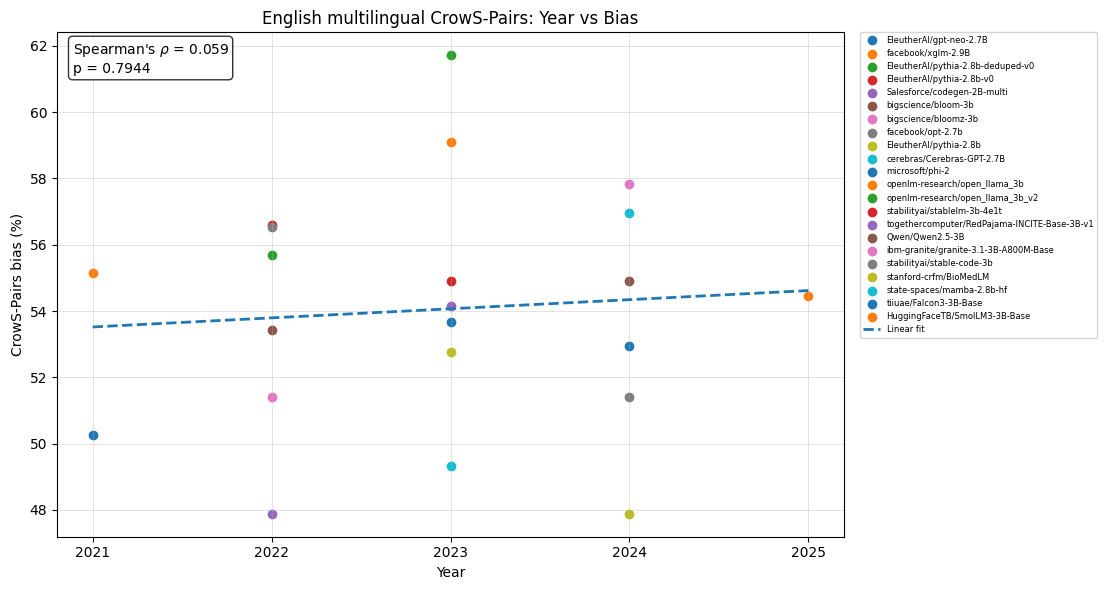

In [ ]:
# english
df_en = df_plot[df_plot["lang"].str.lower() == "english"].copy()

scatter_models_legend(
    df_en,
    xcol="year",
    ycol="crows_bias",
    title="English multilingual CrowS-Pairs: Year vs Bias",
    xlabel="Year",
    ylabel="CrowS-Pairs bias (%)",
    x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside"
)


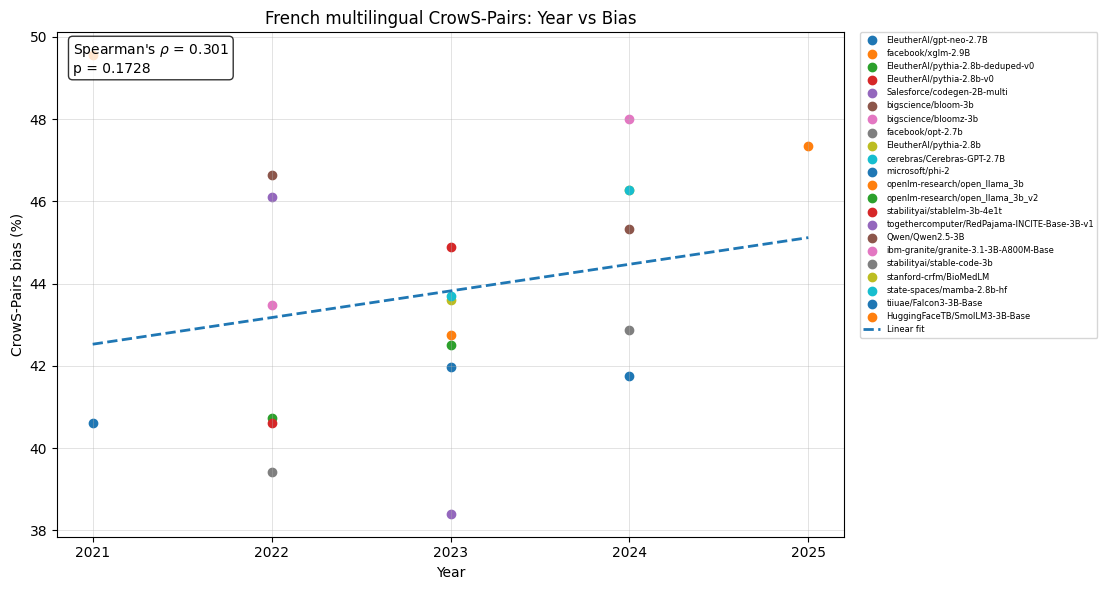

In [ ]:
# french
df_fr = df_plot[df_plot["lang"].str.lower() == "french"].copy()

scatter_models_legend(
    df_fr,
    xcol="year",
    ycol="crows_bias",
    title="French multilingual CrowS-Pairs: Year vs Bias",
    xlabel="Year",
    ylabel="CrowS-Pairs bias (%)",
    x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside"
)

In [6]:
# year-level means by language

year_lang_summary = (
    df_plot.groupby(["lang", "year"])["crows_bias"]
    .agg(["count", "mean", "std"])
    .reset_index()
    .rename(columns={"count": "n"})
)

# 95% confidence interval using normal approximation
year_lang_summary["se"] = year_lang_summary["std"] / np.sqrt(year_lang_summary["n"])
year_lang_summary["ci_low"] = year_lang_summary["mean"] - 1.96 * year_lang_summary["se"]
year_lang_summary["ci_high"] = year_lang_summary["mean"] + 1.96 * year_lang_summary["se"]

year_lang_summary

,lang,year,n,mean,std,se,ci_low,ci_high
0,english,2021,2,52.713178,3.457529,2.444842,47.921288,57.505069
1,english,2022,6,53.587756,3.448192,1.407718,50.828628,56.346884
2,english,2023,7,55.089871,4.115560,1.555535,52.041022,58.138721
3,english,2024,6,53.657325,3.710790,1.514924,50.688074,56.626575
4,english,2025,1,54.442457,NaN,NaN,NaN,NaN
5,french,2021,2,45.080501,6.324748,4.472272,36.314848,53.846154
6,french,2022,6,42.824488,3.050465,1.245347,40.383608,45.265368
7,french,2023,7,42.550473,2.062742,0.779643,41.022372,44.078573
8,french,2024,6,45.080501,2.343402,0.956690,43.205389,46.955613
9,french,2025,1,47.346452,NaN,NaN,NaN,NaN


In [7]:
# spearman correlation between year and bias

rows = []
for lang, sub in df_plot.groupby("lang"):
    rho, p = spearmanr(sub["year"], sub["crows_bias"])
    rows.append({
        "lang": lang,
        "n": len(sub),
        "spearman_rho": rho,
        "p_value": p
    })

df_spearman = pd.DataFrame(rows)
df_spearman

,lang,n,spearman_rho,p_value
0,english,22,0.058949,0.794416
1,french,22,0.301404,0.172840


In [8]:
# paired english and french comparison

df_wide = df_plot.pivot_table(
    index=["year", "model_id"],
    columns="lang",
    values="crows_bias"
).reset_index()

# adjust these names if your language labels differ
en_col = "english"
fr_col = "french"

paired = df_wide.dropna(subset=[en_col, fr_col]).copy()
paired["delta_fr_minus_en"] = paired[fr_col] - paired[en_col]

paired_summary = {
    "n_pairs": len(paired),
    "mean_english": paired[en_col].mean(),
    "mean_french": paired[fr_col].mean(),
    "mean_delta_fr_minus_en": paired["delta_fr_minus_en"].mean(),
    "median_delta_fr_minus_en": paired["delta_fr_minus_en"].median(),
}

stat, p = wilcoxon(paired["delta_fr_minus_en"])
paired_summary["wilcoxon_stat"] = stat
paired_summary["p_value"] = p

paired_summary

{'n_pairs': 22,
 'mean_english': np.float64(54.04401799750637),
 'mean_french': np.float64(43.76321353065539),
 'mean_delta_fr_minus_en': np.float64(-10.280804466850977),
 'median_delta_fr_minus_en': np.float64(-9.749552772808585),
 'wilcoxon_stat': np.float64(0.0),
 'p_value': np.float64(4.76837158203125e-07)}

In [9]:
# correlation between english and french bias across models
rho_cross, p_cross = spearmanr(paired[en_col], paired[fr_col])

pd.DataFrame([{
    "n_pairs": len(paired),
    "spearman_rho_en_fr": rho_cross,
    "p_value": p_cross
}])

,n_pairs,spearman_rho_en_fr,p_value
0,22,-0.057393,0.799732
